In [20]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error

from utils.dataset import Dataset

In [ ]:
# Path
data_root = Path("./data/processed")
path = data_root / "df_all.csv"

# Read data and set to datetime
df = pd.read_csv(filepath_or_buffer=path, sep=",")
df["date"] = pd.to_datetime(df["date"], format="%Y-%m-%d")
df = df.set_index("date")

In [31]:
# Instantiate class and create datasets
dataset = Dataset(data=df)

train_dataset, val_dataset, test_dataset = dataset.create_datasets()

Train size: 5352
Val size: 1529
Test size: 765


In [32]:
# Define model
model = XGBRegressor(
    n_estimators=10000,
    max_depth=3,
    learning_rate=0.01,
    # subsample=0.8,
    # colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    early_stopping_rounds=20
)

In [33]:
# Fit model
model.fit(
    train_dataset[0], 
    train_dataset[1],
    eval_set=[(val_dataset[0], val_dataset[1])],
    )

[0]	validation_0-rmse:0.82730
[1]	validation_0-rmse:0.82274
[2]	validation_0-rmse:0.81824
[3]	validation_0-rmse:0.81380
[4]	validation_0-rmse:0.80943
[5]	validation_0-rmse:0.80511
[6]	validation_0-rmse:0.80088
[7]	validation_0-rmse:0.79665
[8]	validation_0-rmse:0.79252
[9]	validation_0-rmse:0.78841
[10]	validation_0-rmse:0.78442
[11]	validation_0-rmse:0.78043
[12]	validation_0-rmse:0.77653
[13]	validation_0-rmse:0.77264
[14]	validation_0-rmse:0.76883
[15]	validation_0-rmse:0.76528
[16]	validation_0-rmse:0.76156
[17]	validation_0-rmse:0.75790
[18]	validation_0-rmse:0.75428
[19]	validation_0-rmse:0.75081
[20]	validation_0-rmse:0.74748
[21]	validation_0-rmse:0.74392
[22]	validation_0-rmse:0.74108
[23]	validation_0-rmse:0.73784
[24]	validation_0-rmse:0.73461
[25]	validation_0-rmse:0.73187
[26]	validation_0-rmse:0.72869
[27]	validation_0-rmse:0.72561
[28]	validation_0-rmse:0.72231
[29]	validation_0-rmse:0.71968
[30]	validation_0-rmse:0.71670
[31]	validation_0-rmse:0.71371
[32]	validation_0-

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,20
,enable_categorical,False
,eval_metric,None


RMSE: 0.476


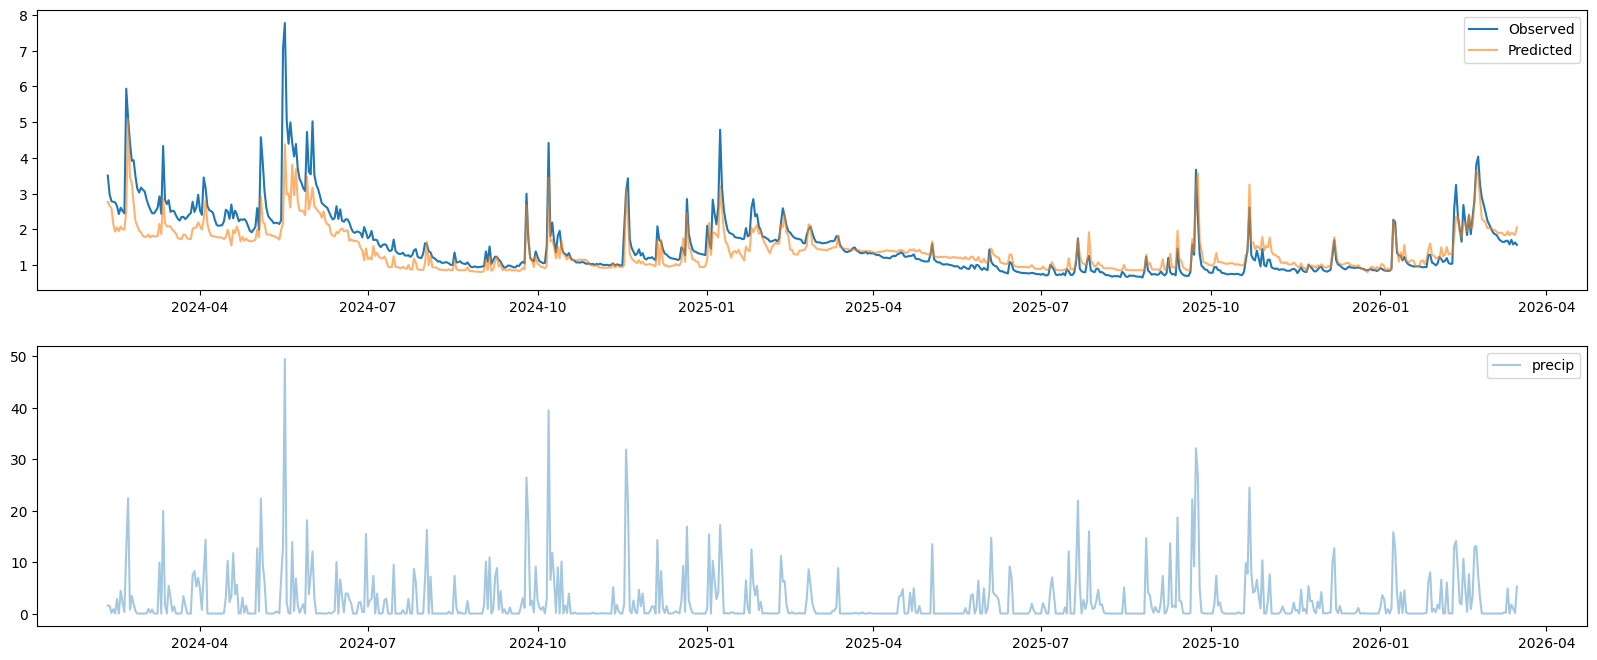

In [35]:
# Predict
y_pred = model.predict(test_dataset[0])


# RMSE metric
rmse = np.sqrt(mean_squared_error(test_dataset[1], y_pred))
print(f"RMSE: {rmse:.3f}")


# Plot Observed v.s Predicted
fig, axs = plt.subplots(nrows=2, figsize=(20,8))

axs[0].plot(test_dataset[1].index, test_dataset[1], label="Observed")
axs[0].plot(test_dataset[1].index, y_pred, label="Predicted", alpha=0.6)
axs[1].plot(test_dataset[1].index, test_dataset[0]["pr"], label="precip", alpha=0.4)

for i in range(2):
    axs[i].legend()

plt.show()